In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
import os

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#DataSet 1 (Health Care)
path_health = kagglehub.dataset_download("rabieelkharoua/chronic-kidney-disease-dataset-analysis")
print("Path to dataset files:", path_health)

#DataSet 2 (Marketing)
path_marketing = kagglehub.dataset_download("rodsaldanha/arketing-campaign")
print("Path to dataset files:", path_marketing)

#DataSet 3 (Energy)
path_energy = kagglehub.dataset_download("guillemservera/fuels-futures-data")
print("Path to dataset files:", path_energy)

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/rabieelkharoua/chronic-kidney-disease-dataset-analysis/versions/1
Path to dataset files: /home/codespace/.cache/kagglehub/datasets/rodsaldanha/arketing-campaign/versions/8
Path to dataset files: /home/codespace/.cache/kagglehub/datasets/guillemservera/fuels-futures-data/versions/191


In [4]:
#Health Dataframe
path_to_file = os.path.join(path_health, "Chronic_Kidney_Dsease_data.csv")
df_health = pd.read_csv(path_to_file)

#Marketing Dataframe
path_to_file_two = os.path.join(path_marketing, "marketing_campaign.csv")
df_marketing = pd.read_csv(path_to_file_two, sep=";")

#Energy Dataframe
path_to_file_three = os.path.join(path_energy, "all_fuels_data.csv")
df_energy = pd.read_csv(path_to_file_three)

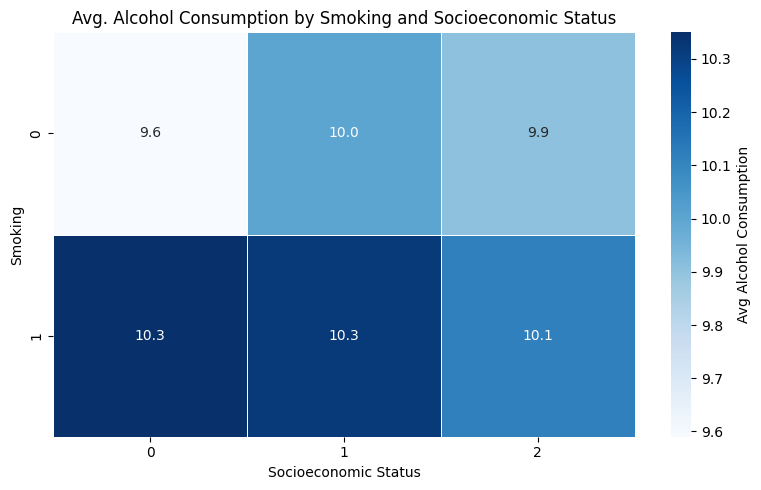

In [5]:
#Smoking, Social Status and Alcohol Consumption 
pivot_mean = df_health.pivot_table(
    index='Smoking',
    columns='SocioeconomicStatus',
    values='AlcoholConsumption',
    aggfunc='mean'
)

# Plot Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot_mean,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={'label': 'Avg Alcohol Consumption'},
    linewidths=0.5,
    square=False
)

# Labels
plt.title("Avg. Alcohol Consumption by Smoking and Socioeconomic Status")
plt.ylabel("Smoking")
plt.xlabel("Socioeconomic Status")
plt.tight_layout()
plt.show()



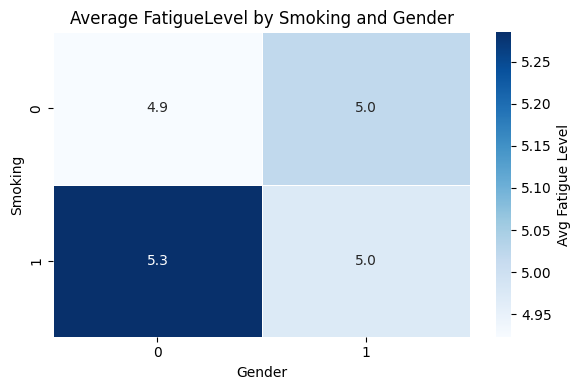

In [6]:
# Smoking, Gender, & Fatigue Level
pivot_mean = df_health.pivot_table(
    index="Smoking",
    columns="Gender",
    values="FatigueLevels",
    aggfunc="mean"
)
# Plot
plt.figure(figsize=(6, 4))
sns.heatmap(
    pivot_mean,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Avg Fatigue Level"},
    linewidths=0.5
)
plt.title("Average FatigueLevel by Smoking and Gender")
plt.ylabel("Smoking")
plt.xlabel("Gender")
plt.tight_layout()
plt.show()

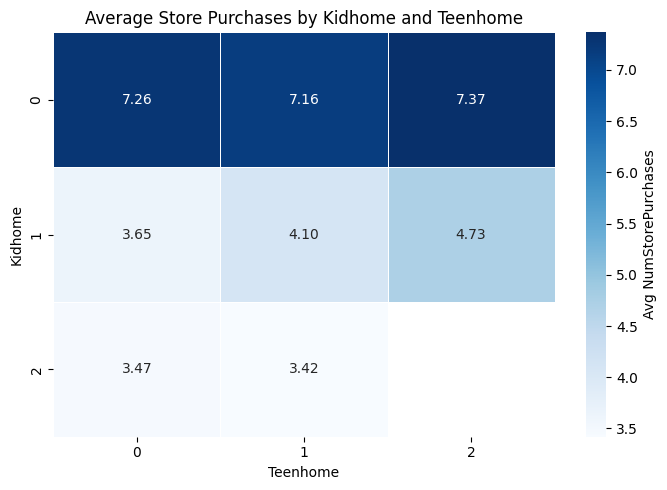

In [7]:
# Marketing Kid at home, teen at home, number of store purchases
pivot_mean = df_marketing.pivot_table(
    index="Kidhome",
    columns="Teenhome",
    values="NumStorePurchases",
    aggfunc="mean"
)
# Plot
plt.figure(figsize=(7, 5))
sns.heatmap(
    pivot_mean,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Avg NumStorePurchases"},
    linewidths=0.5
)

# Labels
plt.title("Average Store Purchases by Kidhome and Teenhome")
plt.ylabel("Kidhome")
plt.xlabel("Teenhome")
plt.tight_layout()
plt.show()



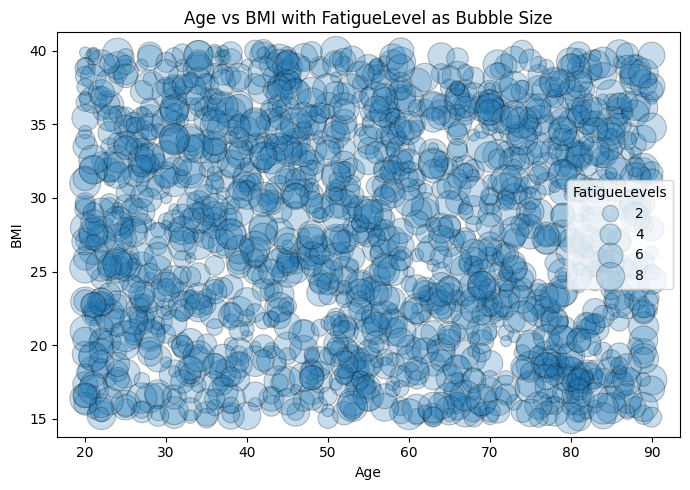

In [8]:
# Bubble BMI, Age, to Fatigue  

subset = df_health[["FatigueLevels", "BMI", "Age"]].dropna()

# Plot
plt.figure(figsize=(7, 5))
ax = sns.scatterplot(
    data=subset,
    x="Age",
    y="BMI",
    size="FatigueLevels",                    
    sizes=(50, 500),              
    alpha=0.25,
    edgecolor="k",
    legend="brief"
)
ax.set_xlabel("Age")
ax.set_ylabel("BMI")
ax.set_title("Age vs BMI with FatigueLevel as Bubble Size")


handles, labels = ax.get_legend_handles_labels()

plt.tight_layout()
plt.show()

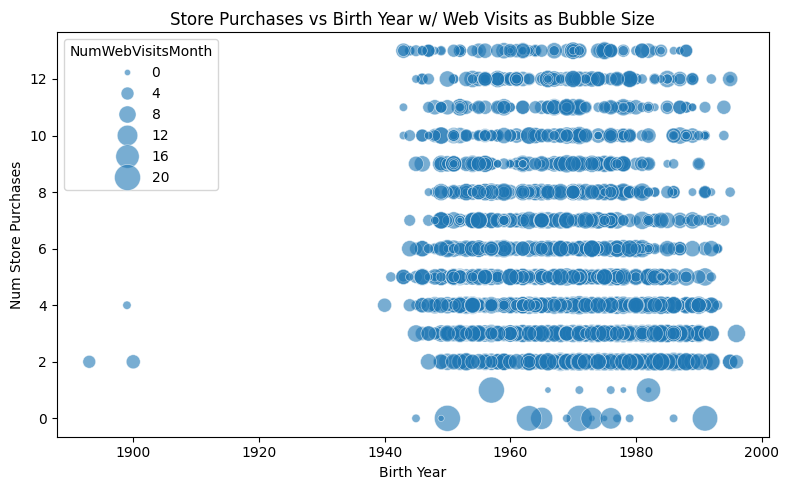

In [9]:
# Bubble Marketing 
plot_df = df_marketing[["Year_Birth", "NumStorePurchases", "NumWebVisitsMonth"]].dropna()

# Plot
plt.figure(figsize=(8, 5))
ax = sns.scatterplot(
    data=plot_df,
    x="Year_Birth",
    y="NumStorePurchases",
    size="NumWebVisitsMonth",
    sizes=(20, 350), 
    alpha=0.6,
    edgecolor="w",
    linewidth=0.5,
    legend="brief"
)
ax.set_title("Store Purchases vs Birth Year w/ Web Visits as Bubble Size")
ax.set_xlabel("Birth Year")
ax.set_ylabel("Num Store Purchases")

handles, labels = ax.get_legend_handles_labels()

plt.tight_layout()
plt.show()



In [10]:
# Change confidential to Nan
df_health["DoctorInCharge"] = df_health["DoctorInCharge"].replace("Confidential", np.nan)



/tmp/ipykernel_2456/1291770701.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_health["DoctorInCharge"] = df_health["DoctorInCharge"].replace("Confidential", np.nan)


/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        27
           1       0.92      1.00      0.96       305

    accuracy                           0.92       332
   macro avg       0.46      0.50      0.48       332
weighted avg       0.84      0.92      0.88       332

ROC AUC: 0.7942926533090469


/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


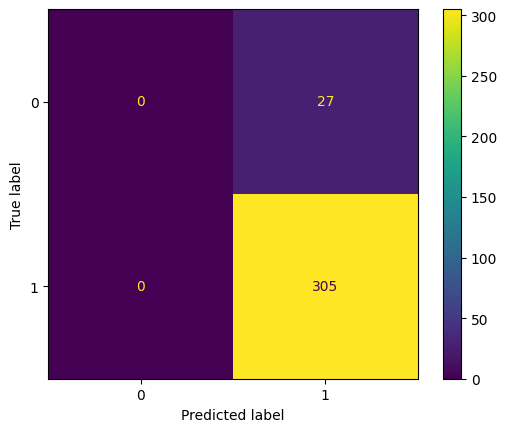

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

# Set x/y
y = df_health["Diagnosis"]  
X = df_health.drop(columns=["Diagnosis", "PatientID"])

# X train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)

# Categorical Columns 
categorical_cols = [
    "Gender",
    "Ethnicity",
    "SocioeconomicStatus",
    "EducationLevel",
    "FamilyHistoryKidneyDisease",
    "FamilyHistoryHypertension",
    "FamilyHistoryDiabetes",
    "PreviousAcuteKidneyInjury",
    "UrinaryTractInfections",
   
]
# Numeric Columns
numeric_cols = [c for c in X.columns if c not in categorical_cols]

# Pre-Transform
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ],
    remainder="drop"
)

# Pipeline
pipeline = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(
        random_state=0,
        class_weight="balanced",  
        n_estimators=200,
        max_depth=None,
        n_jobs=-1
    )),
])


pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]  

print("Classification report:\n", classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

# Confusion Matrix 
ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test)


Missing per column:
 Income    24
dtype: int64


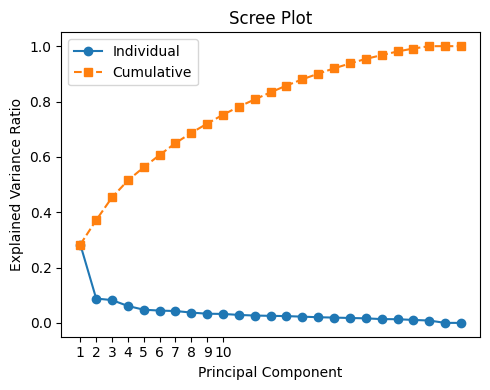

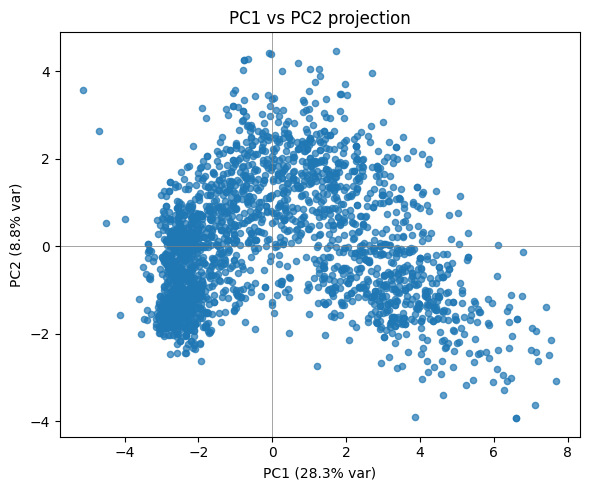

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Marketing PCA
X = df_marketing.copy()

# Drop 
for drop in ["ID"]:
    if drop in X.columns:
        X = X.drop(columns=[drop])

numeric = X.select_dtypes(include=["number"]).copy()

# Pipeline
preprocess_and_pca = Pipeline([
    ("impute", SimpleImputer(strategy="median")),       
    ("scale", StandardScaler()),                        
    ("pca_full", PCA())                                
])

Z = preprocess_and_pca.fit_transform(numeric)  


pca_obj = preprocess_and_pca.named_steps["pca_full"]
explained = pca_obj.explained_variance_ratio_

plt.figure(figsize=(5,4))
components = np.arange(1, len(explained) + 1)
plt.plot(components, explained, "o-", label="Individual")
plt.plot(components, np.cumsum(explained), "s--", label="Cumulative")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.xticks(components[:10])
plt.legend()
plt.tight_layout()
plt.show()

# Scatter 
pca2 = PCA(n_components=2)
pc_scores = pca2.fit_transform(preprocess_and_pca.named_steps["scale"].transform(
    preprocess_and_pca.named_steps["impute"].transform(numeric)
))
pc_df = pd.DataFrame(pc_scores, columns=["PC1", "PC2"])

plt.figure(figsize=(6,5))
plt.scatter(pc_df["PC1"], pc_df["PC2"], alpha=0.7, s=20)
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PC1 vs PC2 projection")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()


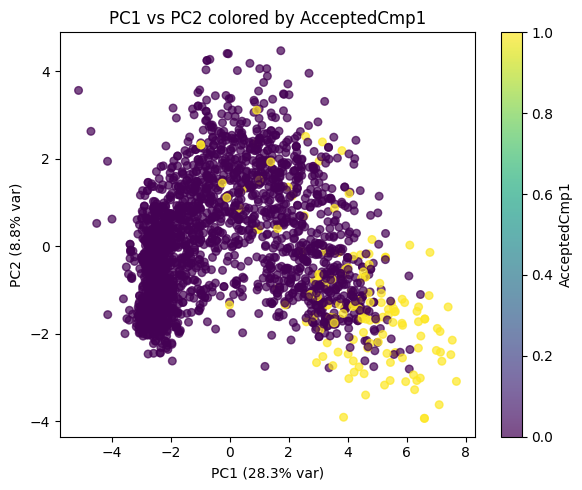

In [20]:
# Response checks
response = df_marketing["AcceptedCmp1"].reset_index(drop=True) 

plt.figure(figsize=(6,5))
scatter = plt.scatter(
    pc_df["PC1"], pc_df["PC2"],
    c=response,                
    cmap="viridis",           
    alpha=0.7,
    s=30
)
plt.colorbar(scatter, label="AcceptedCmp1")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PC1 vs PC2 colored by AcceptedCmp1")
plt.tight_layout()
plt.show()


=== Logistic Regression on PC1/PC2 ===
              precision    recall  f1-score   support

           0       0.90      0.72      0.80       381
           1       0.25      0.54      0.34        67

    accuracy                           0.69       448
   macro avg       0.58      0.63      0.57       448
weighted avg       0.80      0.69      0.73       448

ROC AUC: 0.7200611117640145


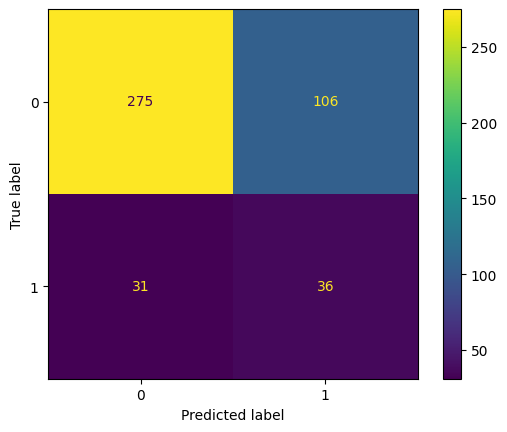

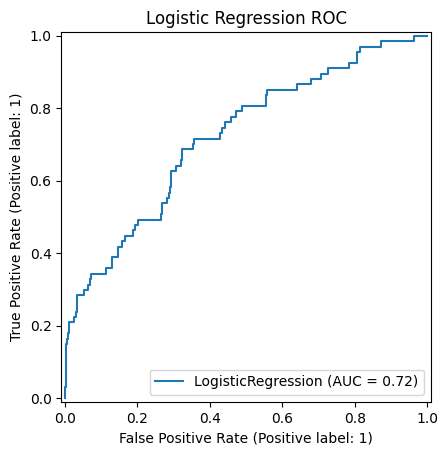

=== Random Forest on PC1/PC2 ===
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       381
           1       0.61      0.37      0.46        67

    accuracy                           0.87       448
   macro avg       0.75      0.67      0.69       448
weighted avg       0.85      0.87      0.86       448

ROC AUC: 0.7976652172209817


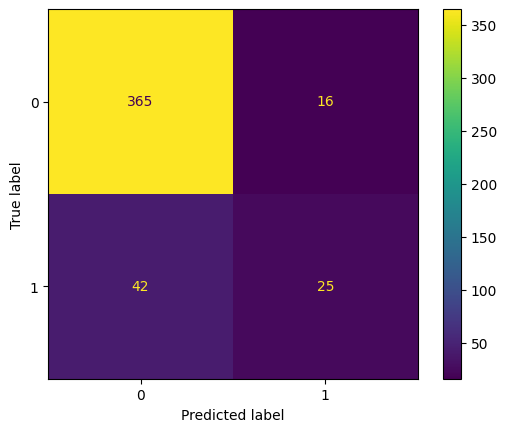

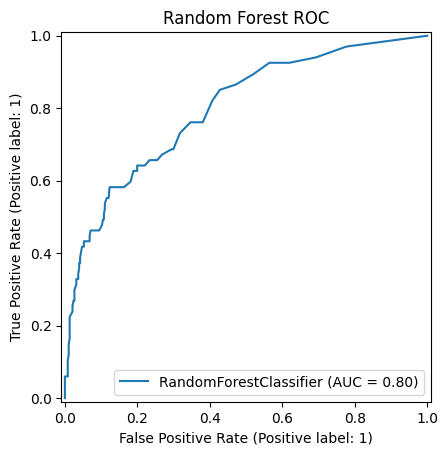

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt
import pandas as pd

# Feature Matrix
pc = pc_df.reset_index(drop=True) 
response = df_marketing["Response"].reset_index(drop=True)  

data = pd.concat([pc, response.rename("Response")], axis=1)

# Train/Test
X = data[["PC1", "PC2"]]
y = data["Response"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=0
)

# Log Re
logreg = LogisticRegression(class_weight="balanced", solver="liblinear", random_state=0)
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)
y_proba_lr = logreg.predict_proba(X_test)[:, 1]

print("=== Logistic Regression on PC1/PC2 ===")
print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lr))
ConfusionMatrixDisplay.from_estimator(logreg, X_test, y_test)
RocCurveDisplay.from_estimator(logreg, X_test, y_test)
plt.title("Logistic Regression ROC")
plt.show()

# RF
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=0
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest on PC1/PC2 ===")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest ROC")
plt.show()


In [22]:
cmp_cols = [f"AcceptedCmp{i}" for i in [1,2,3,4,5]]
print("Total accepts per campaign:")
print(df_marketing[cmp_cols].sum())


Total accepts per campaign:
AcceptedCmp1    144
AcceptedCmp2     30
AcceptedCmp3    163
AcceptedCmp4    167
AcceptedCmp5    163
dtype: int64


In [23]:
for col in cmp_cols:
    print(f"\n{col} vs Response:")
    print(pd.crosstab(df_marketing[col], df_marketing["Response"], margins=True))



AcceptedCmp1 vs Response:
Response         0    1   All
AcceptedCmp1                 
0             1841  255  2096
1               65   79   144
All           1906  334  2240

AcceptedCmp2 vs Response:
Response         0    1   All
AcceptedCmp2                 
0             1896  314  2210
1               10   20    30
All           1906  334  2240

AcceptedCmp3 vs Response:
Response         0    1   All
AcceptedCmp3                 
0             1820  257  2077
1               86   77   163
All           1906  334  2240

AcceptedCmp4 vs Response:
Response         0    1   All
AcceptedCmp4                 
0             1801  272  2073
1              105   62   167
All           1906  334  2240

AcceptedCmp5 vs Response:
Response         0    1   All
AcceptedCmp5                 
0             1835  242  2077
1               71   92   163
All           1906  334  2240
